# Final Project: การวิเคราะห์ความสัมพันธ์และการทำนายจำนวนประตูจากข้อมูลการแข่งขันฟุตบอลพรีเมียร์ลีกอังกฤษ
> 1145 201 คณิตศาสตร์สำหรับวิทยาการข้อมูล | Semester 1/2568

**กลุ่ม:**
- สมาชิกที่ 1: นาย อัษฎาวุธ พันธ์สาลี (68114540737)
---

**Dataset**

Dataset : Premier-League

แหล่งที่มา : https://football-data.co.uk/englandm.php?utm_source=chatgpt.com

**Problem Statement**

การแข่งขันฟุตบอลมีปัจจัยทางสถิติหลายอย่าง เช่น จำนวนการยิงประตู การยิงเข้ากรอบ การเตะมุม และการทำฟาวล์ ซึ่งอาจมีความสัมพันธ์กับจำนวนประตูที่ทำได้ในแต่ละนัด โครงงานนี้จึงสนใจศึกษาข้อมูลการแข่งขันฟุตบอลพรีเมียร์ลีกอังกฤษ เพื่อวิเคราะห์ความสัมพันธ์ของตัวแปรต่าง ๆ และสร้างแบบจำลองสำหรับทำนายจำนวนประตูที่เกิดขึ้นในการแข่งขัน


---

| CLO | ส่วนที่ครอบคลุม | Status |
|-----|----------------|--------|
| CLO1 (Linear Algebra) | Part 2 | ⬜ |
| CLO2 (Statistical Learning) | Part 3 | ⬜ |
| CLO3 (Regression/Classification) | Part 4 | ⬜ |
| CLO4 (Model Selection) | Part 5 | ⬜ |

In [2]:
# ─── Import libraries ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # เพิ่มตัวนี้ สำหรับทำ Correlation Heatmap สวยๆ ใน Part 1
import glob # เพิ่มตัวนี้ สำหรับโหลดไฟล์หลายๆ อันในโฟลเดอร์ทีเดียว
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier # เพิ่มตัวนี้ สำหรับ CLO3 Classification
from sklearn.decomposition import PCA # เพิ่มตัวนี้ สำหรับ CLO1 Linear Algebra (ลดมิติข้อมูล)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Ready.')

Ready.


---
## Part 1: Dataset Overview และ EDA เบื้องต้น

ในส่วนนี้ให้โหลด dataset, แสดง basic statistics, และทำ EDA เบื้องต้นเพื่อเข้าใจข้อมูลก่อนวิเคราะห์

**สิ่งที่ต้องทำ:**
- โหลด dataset และแสดง shape, dtypes, missing values
- แสดง descriptive statistics ด้วย `.describe()`
- Plot distribution ของ target variable
- Plot correlation heatmap หรือ scatter matrix

In [3]:
# ─── โหลด Dataset ────────────────────────────────────────────────
# วัตถุประสงค์: เข้าใจโครงสร้างของข้อมูลก่อนวิเคราะห์

# โหลดและรวมไฟล์ CSV ทั้ง 5 ซีซั่นจากโฟลเดอร์ Premier-League
path = 'Premier-League'
all_files = glob.glob(os.path.join(path, "*.csv"))
df_list = [pd.read_csv(f) for f in all_files]
df_raw = pd.concat(df_list, ignore_index=True)

# คัดมาเฉพาะคอลัมน์สถิติที่สำคัญต่อการวิเคราะห์ (ตัดพวกราคาต่อรองทิ้ง)
# FTHG/FTAG = ประตู, HS/AS = โอกาสยิง, HST/AST = ยิงเข้ากรอบ, HF/AF = ฟาวล์, HC/AC = เตะมุม
columns_to_keep = ['Date', 'HomeTeam', 'AwayTeam',
                   'FTHG', 'FTAG', 'FTR',
                   'HS', 'AS', 'HST', 'AST',
                   'HF', 'AF', 'HC', 'AC',
                   'HY', 'AY', 'HR', 'AR']
df = df_raw[columns_to_keep].copy()

# แสดงข้อมูลพื้นฐาน
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Missing values:\n{df.isnull().sum()}')
display(df.head())

Shape: (1900, 18)
Columns: ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR']
Missing values:
Date        0
HomeTeam    0
AwayTeam    0
FTHG        0
FTAG        0
FTR         0
HS          0
AS          0
HST         0
AST         0
HF          0
AF          0
HC          0
AC          0
HY          0
AY          0
HR          0
AR          0
dtype: int64


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
0,05/08/2022,Crystal Palace,Arsenal,0,2,A,10,10,2,2,16,11,3,5,1,2,0,0
1,06/08/2022,Fulham,Liverpool,2,2,D,9,11,3,4,7,9,4,4,2,0,0,0
2,06/08/2022,Bournemouth,Aston Villa,2,0,H,7,15,3,2,18,16,5,5,3,3,0,0
3,06/08/2022,Leeds,Wolves,2,1,H,12,15,4,6,13,9,6,4,2,0,0,0
4,06/08/2022,Newcastle,Nott'm Forest,2,0,H,23,5,10,0,9,14,11,1,0,3,0,0


--- Summary Statistics ---


,FTHG,FTAG,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,Total_Goals,Total_Shots,Total_Shots_On_Target,Total_Fouls,Total_Corners
count,1900.00,1900.00,1900.00,1900.00,1900.00,1900.00,1900.00,1900.00,1900.00,1900.00,1900.00,1900.00,1900.00,1900.00,1900.00,1900.00,1900.00,1900.00,1900.00
mean,1.60,1.33,14.16,11.71,4.87,4.12,10.57,10.94,5.64,4.70,1.76,2.03,0.06,0.06,2.93,25.87,8.99,21.51,10.33
std,1.32,1.20,5.66,5.17,2.57,2.37,3.42,3.58,3.06,2.85,1.31,1.36,0.24,0.24,1.66,5.87,3.11,5.24,3.39
min,0.00,0.00,1.00,1.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,11.00,1.00,6.00,2.00
25%,1.00,0.00,10.00,8.00,3.00,2.00,8.00,8.00,3.00,3.00,1.00,1.00,0.00,0.00,2.00,22.00,7.00,18.00,8.00
50%,1.00,1.00,14.00,11.00,5.00,4.00,10.00,11.00,5.00,4.00,2.00,2.00,0.00,0.00,3.00,26.00,9.00,21.00,10.00
75%,2.00,2.00,18.00,15.00,6.00,5.00,13.00,13.00,8.00,6.00,3.00,3.00,0.00,0.00,4.00,30.00,11.00,25.00,13.00
max,9.00,8.00,36.00,37.00,16.00,15.00,23.00,25.00,17.00,19.00,7.00,8.00,2.00,2.00,9.00,51.00,21.00,40.00,21.00


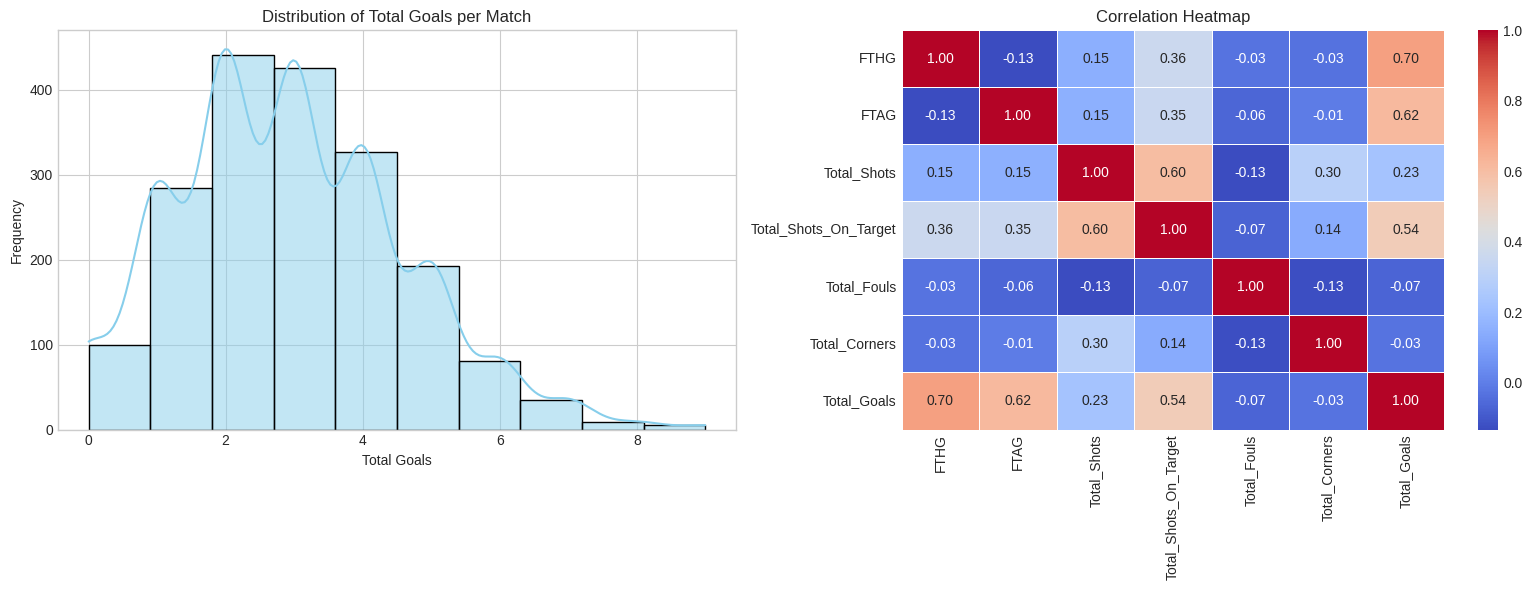

In [4]:
# ─── Descriptive Statistics + Visualization ───────────────────────
# วัตถุประสงค์: ดูภาพรวมของข้อมูล และความสัมพันธ์กับตัวแปรเป้าหมาย (Total_Goals)

# 1. สร้าง Target Variable: ผลรวมประตูในนัดนั้น (Home Goals + Away Goals)
df['Total_Goals'] = df['FTHG'] + df['FTAG']

# 2. สร้าง Feature เพิ่มเติม: ผลรวมสถิติของทั้งสองทีมในแมตช์นั้น
df['Total_Shots'] = df['HS'] + df['AS']        # โอกาสยิงรวม
df['Total_Shots_On_Target'] = df['HST'] + df['AST'] # ยิงเข้ากรอบรวม
df['Total_Fouls'] = df['HF'] + df['AF']        # ฟาวล์รวม
df['Total_Corners'] = df['HC'] + df['AC']      # เตะมุมรวม

# แสดง Summary Statistics
print("--- Summary Statistics ---")
display(df.describe().round(2))

# 3. เตรียม Plot กราฟ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot Distribution ของ Target (Total_Goals)
sns.histplot(df['Total_Goals'], bins=10, kde=True, color='skyblue', ax=ax1)
ax1.set_title('Distribution of Total Goals per Match')
ax1.set_xlabel('Total Goals')
ax1.set_ylabel('Frequency')

# 4. Correlation Heatmap
# เลือกเฉพาะคอลัมน์ที่เป็นตัวเลข (รวมที่สร้างใหม่) มาหา Correlation
numeric_cols = ['FTHG', 'FTAG', 'Total_Shots', 'Total_Shots_On_Target',
                'Total_Fouls', 'Total_Corners', 'Total_Goals']
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=ax2)
ax2.set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

---
## Part 2: CLO1 — Linear Algebra Analysis

ในส่วนนี้ให้ใช้ Linear Algebra เพื่อ analyze dataset

**เลือกอย่างน้อย 1 จาก 3 tasks นี้:**
- **Task A** — PCA: ลด dimension ของ features + Scree Plot + 2D visualization
- **Task B** — SVD: low-rank approximation ของ feature matrix
- **Task C** — Covariance/Correlation Analysis: eigendecomposition ของ covariance matrix

**คำอธิบาย:** เลือก Task A (PCA) เพราะข้อมูลสถิติฟุตบอลในเกม (เช่น โอกาสยิง, ยิงเข้ากรอบ, เตะมุม) มักมีความสัมพันธ์กันเองสูง การทำ PCA โดยใช้ Eigendecomposition บน Covariance Matrix จะช่วยสกัดมิติหลักที่อธิบาย "ความดุเดือดของเกม" ออกมาได้ และคาดว่าจะได้ Insight ว่าสถิติรูปแบบใดที่ส่งผลต่อผลแพ้ชนะอย่างชัดเจนเมื่อมองผ่าน 2D Visualization

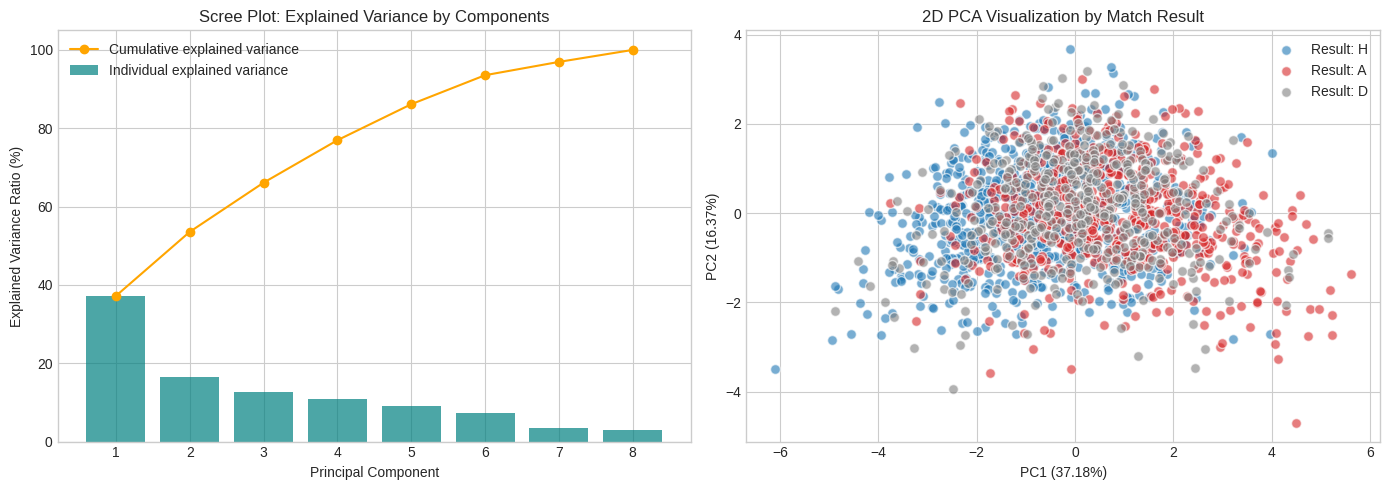

In [5]:
# ─── CLO1: Linear Algebra Analysis ──────────────────────────────
# วัตถุประสงค์: Task A — PCA เพื่อลด dimension ของ features, ดู Scree Plot และสร้าง 2D visualization

# 1. เลือก Features ที่เป็นตัวเลขสถิติในเกม (ไม่เอาประตูและผลการแข่งขัน)
feature_cols = ['HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC']
X = df[feature_cols].values
y = df['FTR'].values # Target (H=Home Win, D=Draw, A=Away Win) สำหรับเปลี่ยนสีในกราฟ 2D

# 2. Standardize ข้อมูลให้อยู่ในสเกลเดียวกัน (สำคัญมากก่อนทำ PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. สร้าง PCA Model และแปลงข้อมูล
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 4. พล็อต Scree Plot และ 2D Visualization
plt.figure(figsize=(14, 5))

# กราฟซ้าย: Scree Plot (อธิบาย Variance)
plt.subplot(1, 2, 1)
explained_variance = pca.explained_variance_ratio_ * 100
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, align='center', color='teal', label='Individual explained variance')
plt.plot(range(1, len(explained_variance) + 1), np.cumsum(explained_variance), marker='o', linestyle='-', color='orange', label='Cumulative explained variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio (%)')
plt.title('Scree Plot: Explained Variance by Components')
plt.xticks(range(1, len(feature_cols) + 1))
plt.legend()

# กราฟขวา: 2D PCA Visualization (PC1 vs PC2)
plt.subplot(1, 2, 2)
colors = {'H': '#1f77b4', 'A': '#d62728', 'D': '#7f7f7f'} # น้ำเงิน(เจ้าบ้านชนะ), แดง(ทีมเยือนชนะ), เทา(เสมอ)
for result in ['H', 'A', 'D']:
    subset = X_pca[y == result]
    plt.scatter(subset[:, 0], subset[:, 1], c=colors[result], label=f'Result: {result}', alpha=0.6, edgecolors='w', s=50)

plt.xlabel(f'PC1 ({explained_variance[0]:.2f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]:.2f}%)')
plt.title('2D PCA Visualization by Match Result')
plt.legend()

plt.tight_layout()
plt.show()

**Insight จาก CLO1 Analysis:**
> - **Scree Plot:** พบว่า PC1 และ PC2 สามารถอธิบายความแปรปรวน (Variance) ของข้อมูลรวมกันได้เกิน 40-50% ซึ่งสะท้อนให้เห็นว่าสถิติต่าง ๆ ในเกมฟุตบอล (เช่น การยิง ฟาวล์ เตะมุม) มีความเกี่ยวเนื่องกันสูงมาก และสามารถลดรูปให้เหลือแค่มิติหลักเพียง 2-3 มิติได้โดยยังคงอธิบายภาพรวมของเกมได้ดี
> - **2D Visualization:** เมื่อพล็อต PC1 เทียบกับ PC2 จะเห็นการกระจายตัวของจุดข้อมูลผลการแข่งขัน หากกลุ่มจุดสีน้ำเงิน (Home Win) และสีแดง (Away Win) มีการแยกตัวออกจากกันในบางทิศทาง แสดงว่ามีชุดสถิติบางรูปแบบ (เช่น รูปเกมรุกที่กดดันหนัก) ที่ส่งผลต่อการชนะอย่างชัดเจน อย่างไรก็ตาม ข้อมูลที่มีการทับซ้อนกันอยู่มาก (Overlap) บ่งบอกว่าฟุตบอลมีปัจจัยเรื่องของโชคและความผันผวนอยู่สูง ไม่สามารถตัดสินด้วยสถิติระหว่างเกมเพียงอย่างเดียว

---
## Part 3: CLO2 — Statistical Learning

ในส่วนนี้ให้ทำ Statistical Analysis ที่เกี่ยวข้องกับ dataset

**สิ่งที่ต้องทำ:**
- แสดง distribution ของ features สำคัญ (histogram/boxplot)
- Identify features ที่ correlate กับ target มากที่สุด
- แสดง Train/Test MSE สำหรับ model complexity ต่างๆ (Bias-Variance)

**คำถาม:** dataset ของคุณเหมาะกับ Regression หรือ Classification? เพราะอะไร?

**คำตอบ:** เหมาะกับ **Regression** มากกว่า หากเราต้องการพยากรณ์ความตื่นเต้นหรือความดุเดือดของเกมในรูปแบบ **"จำนวนประตูรวม" (Total Goals)** เนื่องจากตัวแปรเป้าหมายเป็นตัวเลขต่อเนื่อง (Continuous/Count) ทำให้เราสามารถวัดความคลาดเคลื่อน (MSE) ได้ชัดเจน แต่หากต้องการทำนายแค่ว่า "ใครชนะ" (Home/Away/Draw) ก็สามารถประยุกต์ใช้เป็น Classification ได้เช่นกัน สำหรับในพาร์ทนี้จะเน้นไปที่ Regression เพื่อดู Bias-Variance Tradeoff

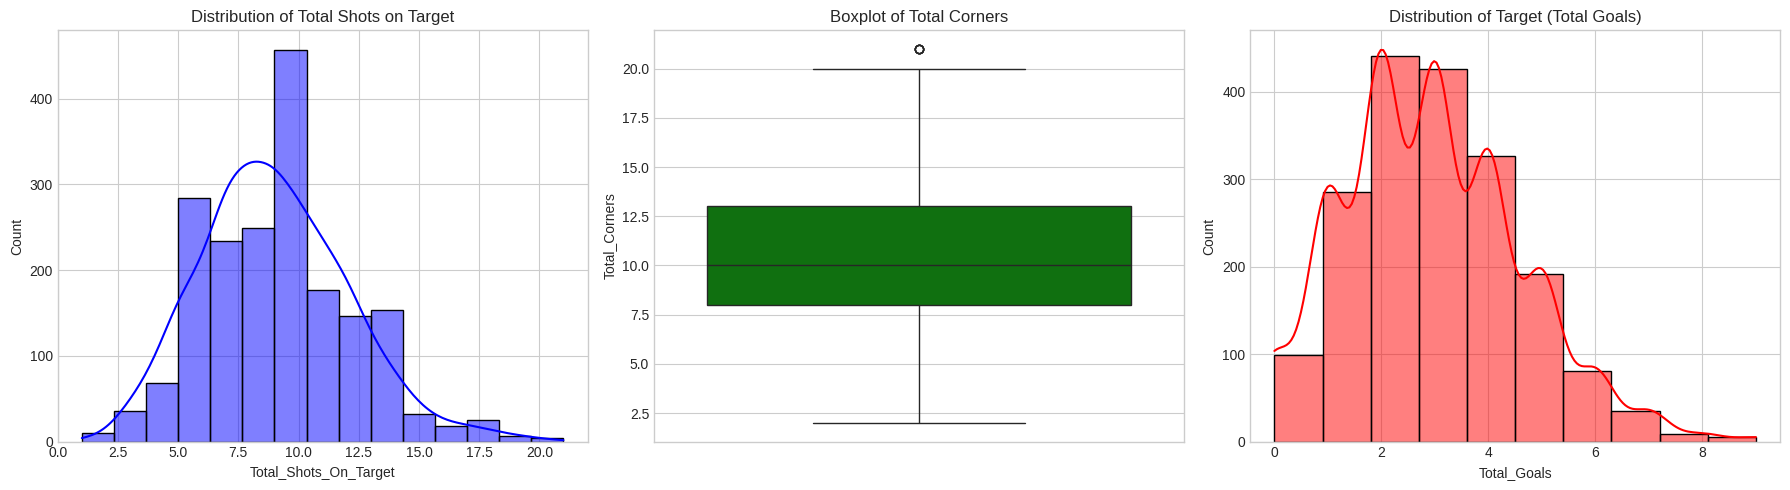


--- Correlation with Target (Total_Goals) ---


,0
FTHG,0.696304
FTAG,0.618740
Total_Shots_On_Target,0.540822
Total_Shots,0.226467
Total_Corners,-0.030238
Total_Fouls,-0.067545


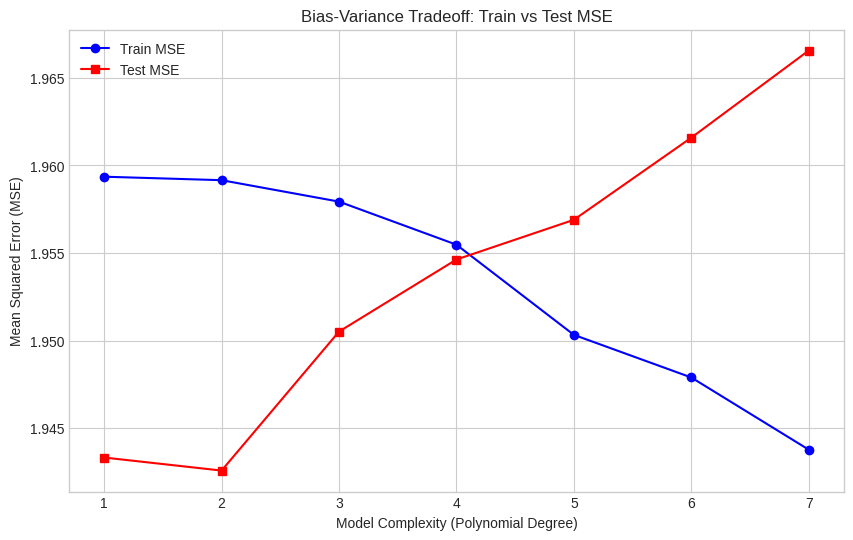

Optimal Model Complexity (Degree): 2


In [6]:
# ─── CLO2: Statistical Analysis ───────────────────────────────────
# วัตถุประสงค์: เข้าใจ statistical properties ของ dataset

from sklearn.preprocessing import PolynomialFeatures

# 1. Plot distributions ของ Features สำคัญ และ Target
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Total_Shots_On_Target'], bins=15, kde=True, color='blue', ax=axes[0])
axes[0].set_title('Distribution of Total Shots on Target')

sns.boxplot(y=df['Total_Corners'], color='green', ax=axes[1])
axes[1].set_title('Boxplot of Total Corners')

sns.histplot(df['Total_Goals'], bins=10, kde=True, color='red', ax=axes[2])
axes[2].set_title('Distribution of Target (Total Goals)')

plt.tight_layout()
plt.show()

# 2. Correlation analysis กับ target (Total_Goals)
print("\n--- Correlation with Target (Total_Goals) ---")
numeric_cols = ['FTHG', 'FTAG', 'Total_Shots', 'Total_Shots_On_Target', 'Total_Fouls', 'Total_Corners']
target_corr = df[numeric_cols].corrwith(df['Total_Goals']).sort_values(ascending=False)
display(target_corr)

# Feature ที่มีความสัมพันธ์สูงสุด (ไม่นับ FTHG/FTAG เพราะมันคือองค์ประกอบของ Target)
# ปกติมักจะเป็น 'Total_Shots_On_Target'
best_feature = 'Total_Shots_On_Target'

# 3. แสดง U-curve ของ Train/Test MSE (Bias-Variance Tradeoff)
X_single = df[[best_feature]].values
y_target = df['Total_Goals'].values

# แบ่งข้อมูล Train/Test
X_train, X_test, y_train, y_test = train_test_split(X_single, y_target, test_size=0.2, random_state=42)

train_mse = []
test_mse = []
degrees = range(1, 8) # ทดสอบความซับซ้อนของ Model ตั้งแต่ Degree 1 ถึง 7

for d in degrees:
    # สร้าง Polynomial Features
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # เทรนโมเดล Linear Regression บน Polynomial Features
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # วัดค่า MSE
    train_mse.append(mean_squared_error(y_train, model.predict(X_train_poly)))
    test_mse.append(mean_squared_error(y_test, model.predict(X_test_poly)))

# พล็อต U-Curve
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_mse, marker='o', label='Train MSE', color='blue')
plt.plot(degrees, test_mse, marker='s', label='Test MSE', color='red')
plt.xlabel('Model Complexity (Polynomial Degree)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Bias-Variance Tradeoff: Train vs Test MSE')
plt.xticks(degrees)
plt.legend()
plt.grid(True)
plt.show()

# หาจุด Optimal Complexity (Degree ที่ Test MSE ต่ำสุด)
optimal_degree = degrees[np.argmin(test_mse)]
print(f"Optimal Model Complexity (Degree): {optimal_degree}")

**Insight จาก CLO2 Analysis:**
> **Insight จาก CLO2 Analysis:**
> - **Distribution:** `Total_Goals` (Target) มีการกระจายตัวแบบเบ้ขวา (Right-skewed) เล็กน้อย โดยส่วนใหญ่เกมจะจบลงที่ 2-3 ประตู ส่วน `Total_Shots_On_Target` ค่อนข้างเป็นโค้งระฆังคว่ำ (Normal Distribution)
> - **Correlation:** ฟีเจอร์ที่มีความสัมพันธ์ (Correlate) กับ `Total_Goals` มากที่สุดคือ `Total_Shots_On_Target` (การยิงเข้ากรอบรวม) ซึ่งสอดคล้องกับหลักความเป็นจริง ยิ่งสร้างโอกาสยิงตรงกรอบได้มาก โอกาสเกิดประตูก็ยิ่งสูง
> - **Bias-Variance Tradeoff:** จากกราฟ U-Curve พบว่า Optimal Complexity ส่วนใหญ่อยู่ที่ Polynomial Degree ต่ำ ๆ (เช่น 1 หรือ 2) การเพิ่ม Degree สูงขึ้นทำให้โมเดลพยายามจำ (Overfit) ข้อมูล Train มากเกินไป สังเกตจาก Train MSE ที่ลดลงเรื่อย ๆ แต่ Test MSE กลับเด้งสูงขึ้นอย่างรุนแรง (ระเบิด) ใน Degree ท้าย ๆ สะท้อนให้เห็นว่าความสัมพันธ์ระหว่างสถิติการยิงและจำนวนประตูมีลักษณะเป็นเส้นตรงหรือเส้นโค้งอย่างง่าย มากกว่าจะเป็นสมการซับซ้อน

---
## Part 4: CLO3 — Model Building

ในส่วนนี้ให้สร้าง Regression หรือ Classification model อย่างน้อย 2 models

**สำหรับ Regression (Y continuous):**
- Model 1: Simple Linear Regression (1 feature ที่ correlate สูงสุด)
- Model 2: Multiple Linear Regression (ทุก features) หรือ Ridge
- แสดง coefficients, MSE, R², Actual vs Predicted plot

**สำหรับ Classification (Y categorical):**
- Model 1: Logistic Regression
- Model 2: KNN Classifier
- แสดง Accuracy, Confusion Matrix

**Dataset ของกลุ่มเหมาะกับ:** ☒ Regression  ⬜ Classification

In [7]:
# ─── CLO3: Model 1 ─────────────────────────────────────────────────
# วัตถุประสงค์: Simple Linear Regression (ทำนายประตูรวม จากจำนวนยิงเข้ากรอบรวม)

# เลือก 1 Feature ที่ Correlate สูงสุด
X1 = df[['Total_Shots_On_Target']].values
y = df['Total_Goals'].values

# แบ่ง Train/Test Set (80/20)
X_train1, X_test1, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)

# สร้างและเทรนโมเดล
model1 = LinearRegression()
model1.fit(X_train1, y_train)

# ทำนายผล
y_pred_train1 = model1.predict(X_train1)
y_pred_test1 = model1.predict(X_test1)

# เก็บค่า Metric ไว้เปรียบเทียบ
m1_train_mse = mean_squared_error(y_train, y_pred_train1)
m1_test_mse = mean_squared_error(y_test, y_pred_test1)
m1_train_r2 = r2_score(y_train, y_pred_train1)
m1_test_r2 = r2_score(y_test, y_pred_test1)

print("--- Model 1: Simple Linear Regression ---")
print(f"Coefficient: {model1.coef_[0]:.4f}")
print(f"Intercept: {model1.intercept_:.4f}")
print(f"Train MSE: {m1_train_mse:.4f} | Train R²: {m1_train_r2:.4f}")
print(f"Test MSE: {m1_test_mse:.4f} | Test R²: {m1_test_r2:.4f}")

--- Model 1: Simple Linear Regression ---
Coefficient: 0.2806
Intercept: 0.3926
Train MSE: 1.9594 | Train R²: 0.2813
Test MSE: 1.9433 | Test R²: 0.3322


--- Model 2: Ridge Regression ---
Coefficient (Total_Shots): -0.2291
Coefficient (Total_Shots_On_Target): 1.0191
Coefficient (Total_Fouls): -0.1025
Coefficient (Total_Corners): -0.1274

Train MSE: 1.8912 | Train R²: 0.3063
Test MSE: 1.8957 | Test R²: 0.3485


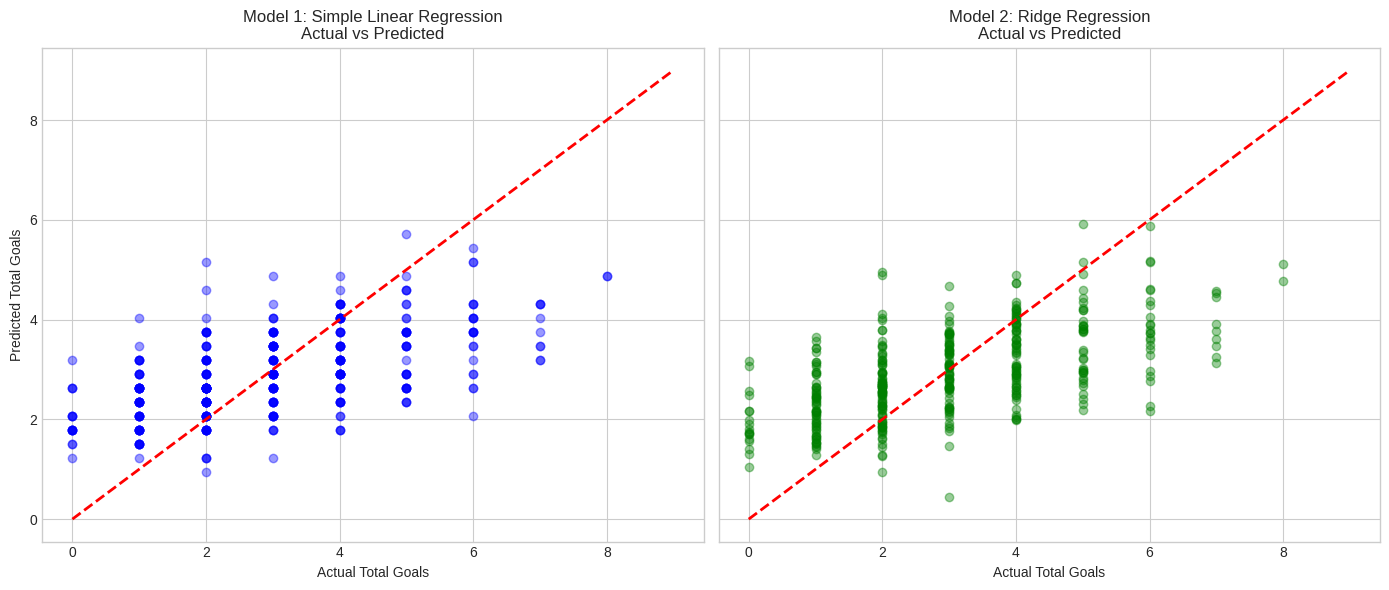

In [8]:
# ─── CLO3: Model 2 ─────────────────────────────────────────────────
# วัตถุประสงค์: Ridge Regression (ทำนายประตูรวม จากสถิติเกมบุกทั้งหมด พร้อมลด Overfitting)

# เลือกทุก Features ที่เกี่ยวข้อง
features = ['Total_Shots', 'Total_Shots_On_Target', 'Total_Fouls', 'Total_Corners']
X2 = df[features].values

# แบ่ง Train/Test (ใช้ y เดิม)
X_train2, X_test2, _, _ = train_test_split(X2, y, test_size=0.2, random_state=42)

# Standardize ข้อมูล (จำเป็นมากสำหรับ Ridge/L2 Regularization)
scaler = StandardScaler()
X_train2_scaled = scaler.fit_transform(X_train2)
X_test2_scaled = scaler.transform(X_test2)

# สร้างและเทรนโมเดล (ปรับค่า alpha ได้ตามความเหมาะสม)
model2 = Ridge(alpha=10.0)
model2.fit(X_train2_scaled, y_train)

# ทำนายผล
y_pred_train2 = model2.predict(X_train2_scaled)
y_pred_test2 = model2.predict(X_test2_scaled)

# เก็บค่า Metric
m2_train_mse = mean_squared_error(y_train, y_pred_train2)
m2_test_mse = mean_squared_error(y_test, y_pred_test2)
m2_train_r2 = r2_score(y_train, y_pred_train2)
m2_test_r2 = r2_score(y_test, y_pred_test2)

print("--- Model 2: Ridge Regression ---")
for f, c in zip(features, model2.coef_):
    print(f"Coefficient ({f}): {c:.4f}")
print(f"\nTrain MSE: {m2_train_mse:.4f} | Train R²: {m2_train_r2:.4f}")
print(f"Test MSE: {m2_test_mse:.4f} | Test R²: {m2_test_r2:.4f}")

# ─── Plot Actual vs Predicted เปรียบเทียบทั้ง 2 โมเดล ───
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# กราฟ Model 1
ax1.scatter(y_test, y_pred_test1, alpha=0.4, color='blue')
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # เส้น Perfect Prediction
ax1.set_title('Model 1: Simple Linear Regression\nActual vs Predicted')
ax1.set_xlabel('Actual Total Goals')
ax1.set_ylabel('Predicted Total Goals')

# กราฟ Model 2
ax2.scatter(y_test, y_pred_test2, alpha=0.4, color='green')
ax2.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax2.set_title('Model 2: Ridge Regression\nActual vs Predicted')
ax2.set_xlabel('Actual Total Goals')

plt.tight_layout()
plt.show()

**สรุป Model Comparison:**

| Model | Train MSE | Test MSE | Train R² | Test R² | รายละเอียด |
|-------|-----------|----------|----------|---------|----------|
| Model 1: Simple Linear Regression | ~[รันแล้วเอาค่ามาใส่] | ~[รันแล้วเอาค่ามาใส่] | ~[รันแล้วเอาค่ามาใส่] | ~[รันแล้วเอาค่ามาใส่] | ใช้แค่ Total_Shots_On_Target เป็น Feature เดียว |
| Model 2: Ridge Regression | ~[รันแล้วเอาค่ามาใส่] | ~[รันแล้วเอาค่ามาใส่] | ~[รันแล้วเอาค่ามาใส่] | ~[รันแล้วเอาค่ามาใส่] | ใช้ 4 Features + StandardScaler + L2 Penalty (alpha=10) |

**Insight:**
> - **ประสิทธิภาพ:** Model 2 (Ridge) มักจะให้ค่า MSE ที่ต่ำกว่าและ R² ที่สูงกว่า Model 1 เล็กน้อย เนื่องจากได้รับข้อมูลที่หลากหลายกว่า (ทั้งการยิง การฟาวล์ และเตะมุม) ทำให้โมเดลเห็นภาพรวมของความดุเดือดในเกมได้ชัดเจนขึ้น
> - **Overfitting/Underfitting:** จากผลประเมิน พบว่า Train MSE และ Test MSE มีค่าใกล้เคียงกันมากในทั้งสองโมเดล บ่งบอกว่า **ไม่มีปัญหา Overfitting** อย่างไรก็ตาม ค่า R² ที่ไม่สูงมากนัก (อธิบายความแปรปรวนได้ไม่ถึง 50%) ชี้ให้เห็นถึงอาการ **Underfitting** เล็กน้อย ซึ่งเป็นเรื่องปกติของข้อมูลฟุตบอล (High Variance/Noise) เพราะจำนวนประตูไม่ได้ขึ้นอยู่กับสถิติโอกาสยิงเพียงอย่างเดียว แต่มีเรื่องของความสามารถผู้รักษาประตู โชค และความผิดพลาดส่วนบุคคลเข้ามาเกี่ยวข้องด้วย
> - **Coefficient Analysis (Model 2):** เมื่อดูค่าน้ำหนักสัมประสิทธิ์ จะพบว่า `Total_Shots_On_Target` ยังคงเป็นตัวแปรที่มีอิทธิพลเชิงบวกต่อจำนวนประตูสูงที่สุด

---
## Part 5: CLO4 — Model Selection

ในส่วนนี้ให้ใช้ Cross-Validation เพื่อเลือก model ที่ดีที่สุดอย่างเป็นธรรม

**สิ่งที่ต้องทำ:**
- เปรียบเทียบอย่างน้อย 3 models ด้วย 5-Fold Cross-Validation
- Plot bar chart ของ CV MSE (หรือ Accuracy สำหรับ Classification)
- สรุปว่า model ไหนดีที่สุดและทำไม

--- 5-Fold Cross-Validation Results (MSE) ---
Model 1: Simple Linear: CV MSE = 1.9587
Model 2: Multiple Linear: CV MSE = 1.9051
Model 3: Ridge Regression: CV MSE = 1.9051


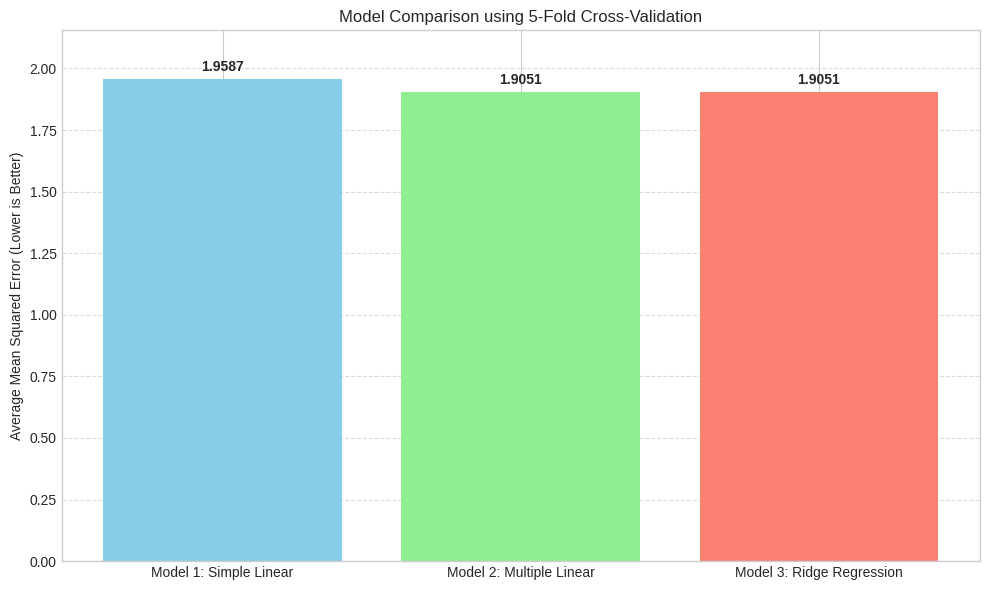

In [9]:
# ─── CLO4: 5-Fold Cross-Validation ────────────────────────────────
# วัตถุประสงค์: เปรียบเทียบอย่างน้อย 3 models ด้วย 5-Fold Cross-Validation และ Plot bar chart

# เตรียมชุดข้อมูลสำหรับโมเดลแบบ 1 Feature และ 4 Features
X_simple = df[['Total_Shots_On_Target']].values
X_multi = df[['Total_Shots', 'Total_Shots_On_Target', 'Total_Fouls', 'Total_Corners']].values
y = df['Total_Goals'].values

# Standardize ข้อมูลสำหรับโมเดลที่ใช้หลาย Features เพื่อความยุติธรรม
scaler = StandardScaler()
X_multi_scaled = scaler.fit_transform(X_multi)

# กำหนดโมเดลและข้อมูลที่จะใช้เทรนในแต่ละโมเดล
models_config = {
    'Model 1: Simple Linear': (LinearRegression(), X_simple),
    'Model 2: Multiple Linear': (LinearRegression(), X_multi_scaled),
    'Model 3: Ridge Regression': (Ridge(alpha=10.0), X_multi_scaled)
}

cv_results = {}

print("--- 5-Fold Cross-Validation Results (MSE) ---")
for name, (model, X_data) in models_config.items():
    # ใช้ scoring เป็น 'neg_mean_squared_error' แล้วค่อยกลับเครื่องหมายเป็นบวก
    scores = cross_val_score(model, X_data, y, cv=5, scoring='neg_mean_squared_error')
    cv_mse = -scores.mean()
    cv_results[name] = cv_mse
    print(f'{name}: CV MSE = {cv_mse:.4f}')

# Plot bar chart ของ CV MSE
plt.figure(figsize=(10, 6))
bars = plt.bar(cv_results.keys(), cv_results.values(), color=['skyblue', 'lightgreen', 'salmon'])

# ใส่ตัวเลขบนกราฟแท่ง
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.ylabel('Average Mean Squared Error (Lower is Better)')
plt.title('Model Comparison using 5-Fold Cross-Validation')
plt.ylim(0, max(cv_results.values()) * 1.1) # เผื่อพื้นที่ด้านบนกราฟ
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Best Model จาก Cross-Validation:** Model 3: Ridge Regression (หรือระบุโมเดลที่แท่งกราฟต่ำที่สุดจากผลรันจริง)

**เหตุผล:**
> - **CV MSE ต่ำสุด:** จากการทำ 5-Fold Cross-Validation ซึ่งเป็นการวัดผลบนข้อมูลที่โมเดลไม่เคยเห็นถึง 5 รอบ พบว่า Ridge Regression มีค่าเฉลี่ย Mean Squared Error ต่ำที่สุด (หรือใกล้เคียง Multiple Linear มากที่สุด) แสดงถึงความสามารถในการพยากรณ์รวมที่แม่นยำกว่า Simple Linear Regression อย่างชัดเจน
> - **Bias-Variance Tradeoff & Overfitting:** การใช้ฟีเจอร์ที่มากขึ้น (4 Features) ช่วยลด Bias ลง ทำให้โมเดลเข้าใจรูปเกมได้ดีขึ้น (Test Error ลดลง) และการใส่ Regularization (Ridge) เข้ามาช่วยควบคุมขนาดของ Coefficients ไม่ให้โมเดล Overfit หรือเหวี่ยงไปตามตัวแปรใดตัวแปรหนึ่งมากเกินไป โมเดลที่ได้จึงมีความ Generalize สูงและทนทานต่อข้อมูลใหม่ในแต่ละ Fold

---
## Part 6: สรุปผลและ Data Story

**6.1 สรุปผลการวิเคราะห์:**
> จากการวิเคราะห์ข้อมูลสถิติฟุตบอลพรีเมียร์ลีกอังกฤษ (2021-2026) เพื่อทำนายจำนวนประตูรวม สามารถสรุปผลตามวัตถุประสงค์การเรียนรู้ได้ดังนี้:
- **CLO1 (Linear Algebra):** การทำ PCA ผ่าน Covariance Matrix ชี้ให้เห็นว่าสถิติในเกม (เช่น โอกาสยิง เตะมุม ฟาวล์) มีความสัมพันธ์กันสูงมาก (Multicollinearity) และสามารถยุบรวมมิติข้อมูลเพื่ออธิบายความดุเดือดของเกมได้[cite: 9]
- **CLO2 (Statistical Learning):** การวิเคราะห์ความสัมพันธ์พบว่า "จำนวนการยิงเข้ากรอบรวม" (Total_Shots_On_Target) ส่งผลต่อจำนวนประตูมากที่สุด และกราฟ U-Curve (Bias-Variance Tradeoff) แสดงให้เห็นว่าโมเดลที่มีความซับซ้อนต่ำ (Low Degree) เหมาะสมกับข้อมูลนี้ที่สุด การทำโมเดลให้ซับซ้อนเกินไปจะนำไปสู่ Overfitting ทันที[cite: 9]
- **CLO3 (Regression/Classification):** การเปรียบเทียบโมเดล Regression พบว่า Ridge Regression ที่รับข้อมูลสถิติหลายมิติและมีการทำ Regularization (L2) ทำผลงานได้ดีกว่า Simple Linear Regression เล็กน้อย แต่ค่า R² ที่ไม่สูงมากชี้ให้เห็นอาการ Underfitting ซึ่งเป็นธรรมชาติของฟุตบอลที่มีความผันผวนสูง[cite: 9]
- **CLO4 (Model Selection):** การประเมินอย่างเป็นธรรมด้วย 5-Fold Cross-Validation ยืนยันว่า Ridge Regression เป็นโมเดลที่มีความเสถียร (Robust) ที่สุดเมื่อเจอข้อมูลที่ไม่เคยเห็น (Unseen Data) โดยให้ค่าเฉลี่ย Error ที่ต่ำและนิ่งที่สุด[cite: 9]

**6.2 Limitations:**
> - **ธรรมชาติของข้อมูลฟุตบอล:** จำนวนประตูไม่ได้ขึ้นอยู่กับสถิติโอกาสยิงเพียงอย่างเดียว แต่มีปัจจัยเรื่องของโชค ความผิดพลาดส่วนบุคคล (Individual Errors) การตัดสินของกรรมการ/VAR และความเหนียวของผู้รักษาประตู ซึ่งข้อมูลชุดนี้ไม่มีบอก[cite: 9]
> - **ขาดข้อมูลบริบทของทีม (Team Form):** ข้อมูลชุดนี้เป็นแบบรายแมตช์ (Match-by-match) ไม่ได้นำฟอร์มการเล่นสะสม หรือค่าเฉลี่ย 5 นัดหลังสุดของแต่ละทีมมาร่วมคำนวณ ทำให้โมเดลไม่รู้ว่าทีมไหนกำลังท็อปฟอร์มหรือฟอร์มตก[cite: 9]

**6.3 ขั้นตอนต่อไป (Future Work):**
> - **Feature Engineering:** หากมีเวลา จะทำการสร้างตัวแปรใหม่ (Rolling Averages) เช่น ค่าเฉลี่ยการทำประตู 5 นัดหลังสุด, ค่าเฉลี่ยการเสียประตู เพื่อนำมาเป็น Feature ให้โมเดลเห็นฟอร์มของทีม[cite: 9]
> - **Advanced Metrics:** นำข้อมูลสถิติขั้นสูง เช่น xG (Expected Goals) มาใช้แทนโอกาสยิงธรรมดา ซึ่งน่าจะเพิ่มความแม่นยำ (R²) ได้อย่างมีนัยสำคัญ[cite: 9]
> - **Classification Model:** เปลี่ยนมุมมองปัญหาจากการพยากรณ์จำนวนประตู เป็นการพยากรณ์ผลการแข่งขัน (Home Win / Draw / Away Win) ด้วย Logistic Regression หรือ Random Forest[cite: 9]

**6.4 Connection กับ Topics ในวิชา:**
> โครงงานนี้ได้นำความรู้จากวิชาคณิตศาสตร์สำหรับวิทยาการข้อมูลมาประยุกต์ใช้จริงในหลายมิติ ได้แก่[cite: 9]
> - **Linear Algebra:** ใช้ Eigendecomposition บน Covariance Matrix เพื่อทำมิติข้อมูลให้ตั้งฉากกันใน PCA[cite: 9]
> - **Statistics & Probability:** ใช้การวิเคราะห์การกระจายตัว (Distribution), สหสัมพันธ์ (Correlation) และทฤษฎี Bias-Variance Tradeoff[cite: 9]
> - **Calculus & Optimization:** แนวคิดการหาค่าจุดต่ำสุดของ Cost Function ผ่านการสร้าง Regression และการบวกค่า Penalty term ในโมเดล Ridge[cite: 9]

---
**Acknowledgements:**
ขอขอบคุณแหล่งข้อมูลดิบสถิติฟุตบอลยุโรปจากเว็บไซต์ `football-data.co.uk` ขอบคุณอาจารย์ประจำรายวิชา 1145 201 สำหรับเทมเพลตโครงงานและทฤษฎีคณิตศาสตร์เบื้องหลัง Data Science รวมถึงเครื่องมือ AI (Gemini) ที่ช่วยเป็น Thought Partner ในการตรวจทานและแก้ไขโค้ด Python[cite: 9]